# 02 — Preprocessing Pipeline

Full preprocessing pipeline applied to **both** Subject 1 records:
- `AccTempEDA` — ax, ay, az, temp, EDA @ 8 Hz
- `SpO2HR` — SpO2, hr @ 1 Hz

Steps per record:
1. Low-pass Butterworth filter (zero-phase)
2. Per-subject Z-score normalization (stats over full recording, before segmentation)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from src.preprocessing import load_record, filter_signal, normalize_record, subject_paths

## Load Subject 1 — both records

In [2]:
eda_path, hr_path = subject_paths(1)

record_eda = load_record(eda_path, annotation_extension='atr')  # has annotations
record_hr  = load_record(hr_path,  annotation_extension=None)   # no annotation file

# SpO2HR has no annotation file — copy phase boundaries from AccTempEDA, rescaled to 1 Hz
boundary_s = [s / record_eda['sampling_frequency'] for s in record_eda['annotation_samples']]
record_hr['annotation_samples'] = [round(t * record_hr['sampling_frequency']) for t in boundary_s]
record_hr['annotation_labels']  = record_eda['annotation_labels']

for name, record in [('AccTempEDA', record_eda), ('SpO2HR', record_hr)]:
    duration = record['signal'].shape[0] / record['sampling_frequency'] / 60
    print(f"{name}")
    print(f"  channels : {record['signal_names']}")
    print(f"  sampling_frequency : {record['sampling_frequency']} Hz")
    print(f"  shape    : {record['signal'].shape}  (samples x channels)")
    print(f"  duration : {duration:.1f} min")
    print()

AccTempEDA
  channels : ['ax', 'ay', 'az', 'temp', 'EDA']
  sampling_frequency : 8 Hz
  shape    : (18343, 5)  (samples x channels)
  duration : 38.2 min

SpO2HR
  channels : ['SpO2', 'hr']
  sampling_frequency : 1 Hz
  shape    : (2299, 2)  (samples x channels)
  duration : 38.3 min



## Apply Low-Pass Butterworth Filter

| Record | fs | Nyquist | Cutoff |
|---|---|---|---|
| AccTempEDA | 8 Hz | 4 Hz | 1.0 Hz |
| SpO2HR | 1 Hz | 0.5 Hz | 0.1 Hz |

Both use order-4, zero-phase (`filtfilt`).

In [3]:
eda_signal_filtered = filter_signal(record_eda['signal'], sampling_frequency=record_eda['sampling_frequency'], cutoff=1.0)
hr_signal_filtered  = filter_signal(record_hr['signal'],  sampling_frequency=record_hr['sampling_frequency'],  cutoff=0.1)

record_eda_filtered = {**record_eda, 'signal': eda_signal_filtered}
record_hr_filtered  = {**record_hr,  'signal': hr_signal_filtered}

print("AccTempEDA: low-pass at 1.0 Hz (order 4, zero-phase)")
print("SpO2HR    : low-pass at 0.1 Hz (order 4, zero-phase)")

AccTempEDA: low-pass at 1.0 Hz (order 4, zero-phase)
SpO2HR    : low-pass at 0.1 Hz (order 4, zero-phase)


## Before vs After — AccTempEDA (8 Hz, cutoff 1.0 Hz)

Raw signal in blue, filtered in orange. Phase labels on top subplot.

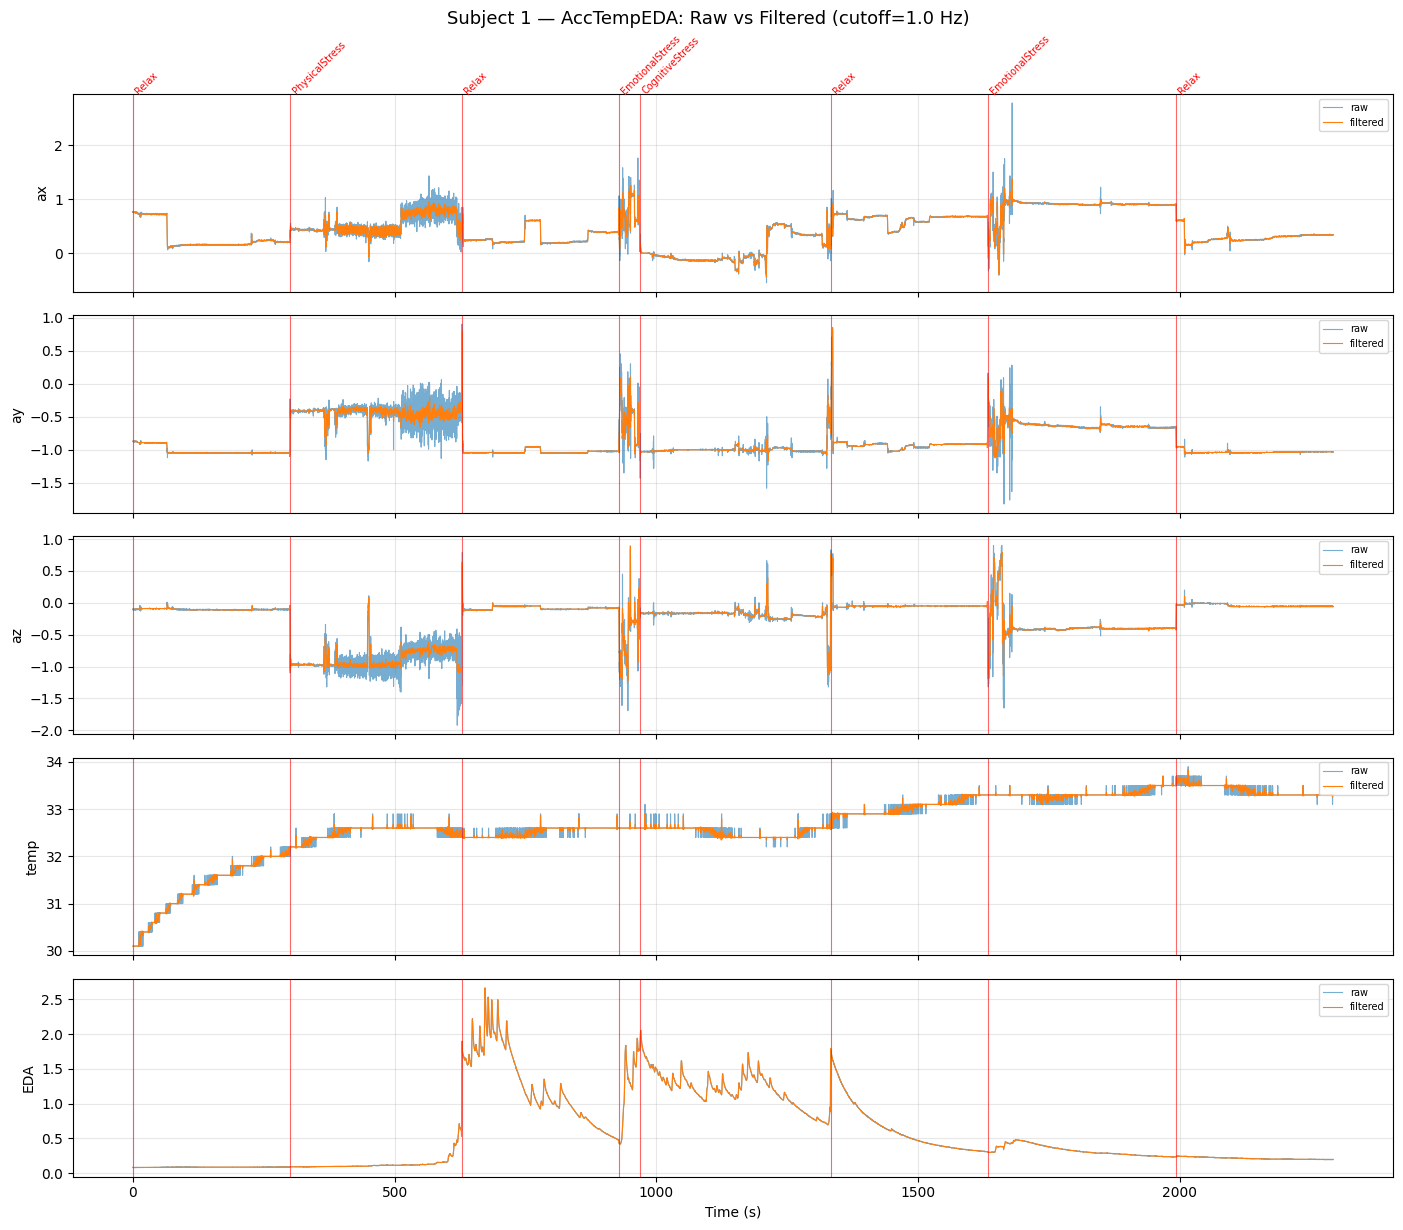

In [4]:
def plot_before_after(record_raw, filtered_signal, title):
    sampling_frequency = record_raw['sampling_frequency']
    channel_names = record_raw['signal_names']
    num_channels = len(channel_names)
    time_axis = np.arange(record_raw['signal'].shape[0]) / sampling_frequency

    # Convert phase boundary sample indices to seconds
    phase_times  = [s / sampling_frequency for s in record_raw['annotation_samples']]
    phase_labels = record_raw['annotation_labels']

    fig, axes = plt.subplots(num_channels, 1, figsize=(14, 2.5 * num_channels), sharex=True)
    if num_channels == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13)

    for channel_idx, ax in enumerate(axes):
        # Overlay raw and filtered signals
        ax.plot(time_axis, record_raw['signal'][:, channel_idx], lw=0.8, alpha=0.6, label='raw')
        ax.plot(time_axis, filtered_signal[:, channel_idx], lw=0.8, label='filtered')

        # Draw a vertical red line at each phase boundary
        for phase_time, phase_label in zip(phase_times, phase_labels):
            ax.axvline(phase_time, color='red', lw=0.8, alpha=0.6)

            # Only label phases on the top subplot to avoid clutter
            if channel_idx == 0:
                ax.text(phase_time + 1, ax.get_ylim()[1], phase_label,
                        fontsize=7, color='red', rotation=45)

        ax.set_ylabel(channel_names[channel_idx])
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

plot_before_after(record_eda, eda_signal_filtered, 'Subject 1 — AccTempEDA: Raw vs Filtered (cutoff=1.0 Hz)')

## Before vs After — SpO2HR (1 Hz, cutoff 0.1 Hz)

Raw signal in blue, filtered in orange. Phase labels on top subplot.

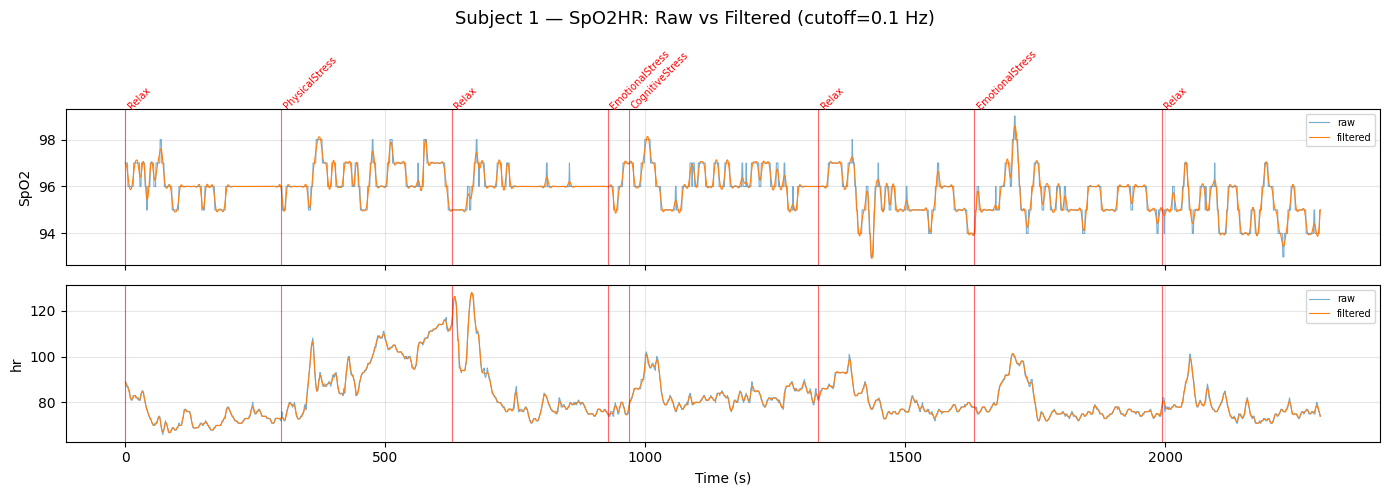

In [5]:
plot_before_after(record_hr, hr_signal_filtered, 'Subject 1 — SpO2HR: Raw vs Filtered (cutoff=0.1 Hz)')

## Apply Per-Subject Z-Score Normalization

Stats (mean, std) computed over the entire recording before segmentation.

In [6]:
record_eda_normalized = normalize_record(record_eda_filtered)
record_hr_normalized  = normalize_record(record_hr_filtered)

for record_label, record_before, record_after in [
    ('AccTempEDA', record_eda_filtered, record_eda_normalized),
    ('SpO2HR',     record_hr_filtered,  record_hr_normalized),
]:
    print(f"\n{record_label}")
    print(f"  {'Channel':<8} {'mean before':>12} {'std before':>11} {'mean after':>11} {'std after':>10}")
    print('  ' + '-' * 55)
    for i, channel in enumerate(record_before['signal_names']):
        mean_before = record_before['signal'][:, i].mean()
        std_before = record_before['signal'][:, i].std()
        mean_after = record_after['signal'][:, i].mean()
        std_after = record_after['signal'][:, i].std()
        print(f"  {channel:<8} {mean_before:>12.4f} {std_before:>11.4f} {mean_after:>11.6f} {std_after:>10.6f}")


AccTempEDA
  Channel   mean before  std before  mean after  std after
  -------------------------------------------------------
  ax             0.4341      0.3160   -0.000000   1.000000
  ay            -0.8526      0.2410    0.000000   1.000000
  az            -0.2597      0.3066   -0.000000   1.000000
  temp          32.6773      0.6638    0.000000   1.000000
  EDA            0.5714      0.5351   -0.000000   1.000000

SpO2HR
  Channel   mean before  std before  mean after  std after
  -------------------------------------------------------
  SpO2          95.8350      0.8479   -0.000000   1.000000
  hr            82.1532     10.6307   -0.000000   1.000000


## Normalized Signals — All Phases

EDA, accelerometer magnitude, skin temperature, HR, and SpO2 after full preprocessing (filter → z-score).

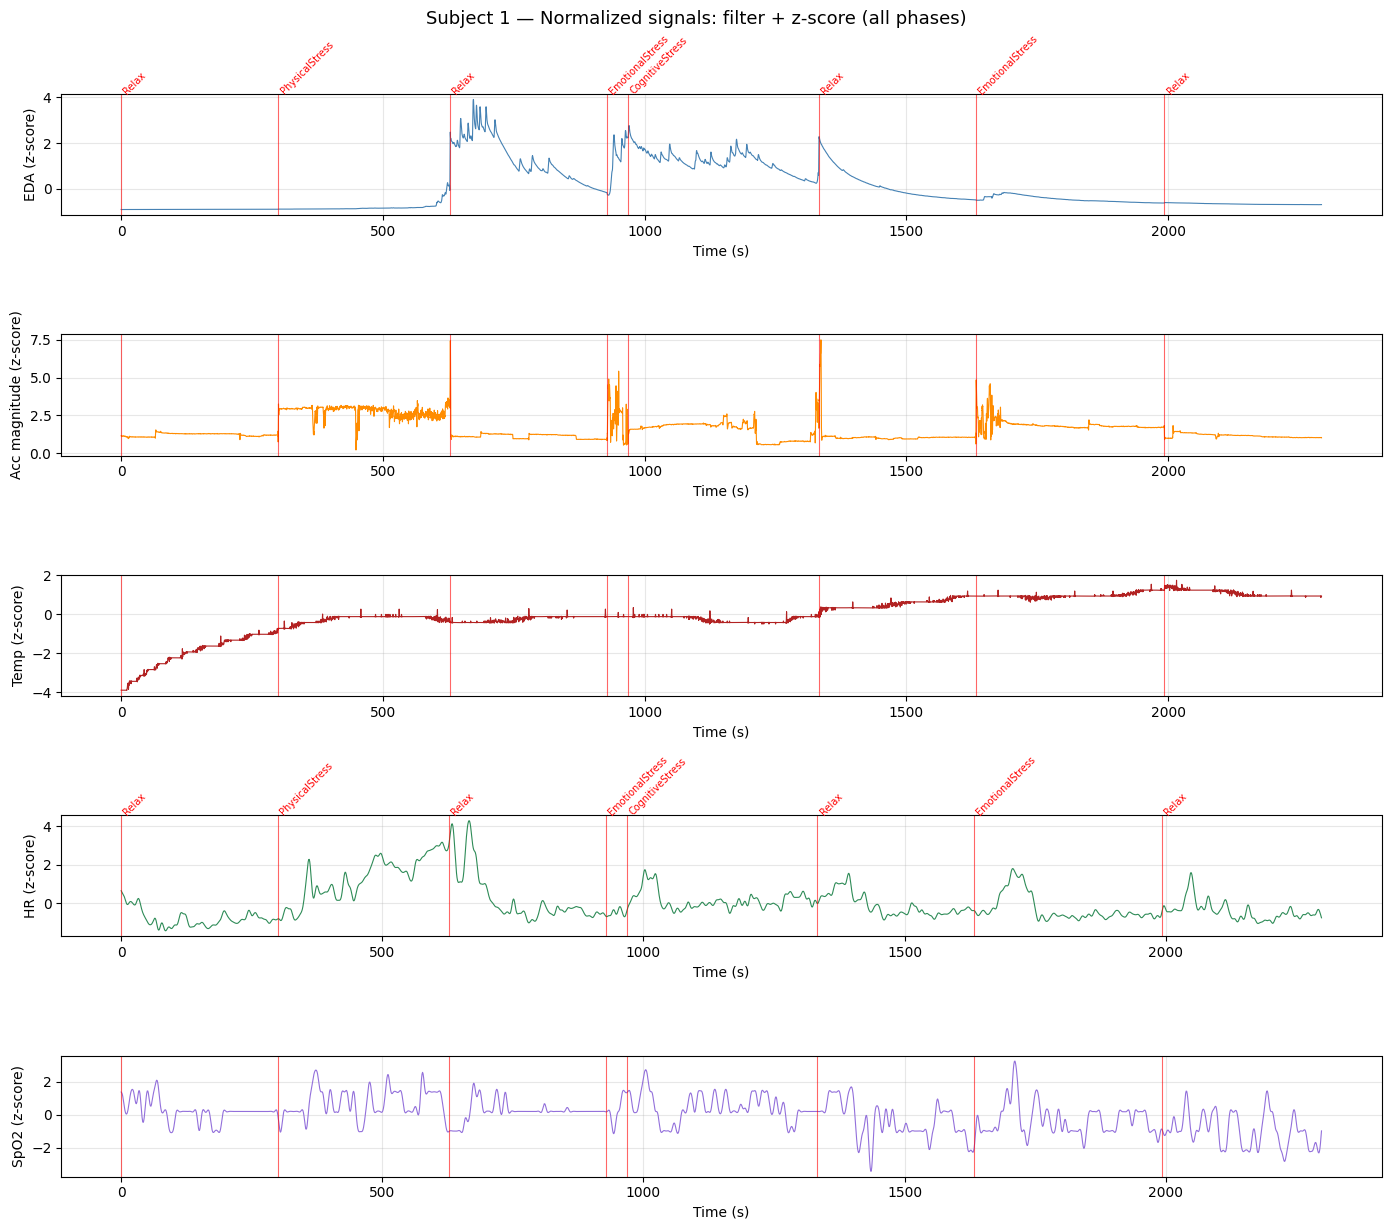

In [7]:
eda_signal = record_eda_normalized['signal']
hr_signal = record_hr_normalized['signal']
eda_channel_names = record_eda_normalized['signal_names']
hr_channel_names = record_hr_normalized['signal_names']

# Build time axes and derived signals
time_eda = np.arange(len(eda_signal)) / record_eda_normalized['sampling_frequency']
time_hr  = np.arange(len(hr_signal)) / record_hr_normalized['sampling_frequency']
acceleration_magnitude = np.sqrt(eda_signal[:, eda_channel_names.index('ax')]**2 +
                  eda_signal[:, eda_channel_names.index('ay')]**2 +
                  eda_signal[:, eda_channel_names.index('az')]**2)

plot_specs = [
    (time_eda, eda_signal[:, eda_channel_names.index('EDA')],  'EDA (z-score)',           'steelblue',    record_eda_normalized),
    (time_eda, acceleration_magnitude,                         'Acc magnitude (z-score)', 'darkorange',   record_eda_normalized),
    (time_eda, eda_signal[:, eda_channel_names.index('temp')], 'Temp (z-score)',          'firebrick',    record_eda_normalized),
    (time_hr,  hr_signal[:, hr_channel_names.index('hr')],     'HR (z-score)',            'seagreen',     record_hr_normalized),
    (time_hr,  hr_signal[:, hr_channel_names.index('SpO2')],   'SpO2 (z-score)',          'mediumpurple', record_hr_normalized),
]

fig, axes = plt.subplots(len(plot_specs), 1, figsize=(14, 2.5 * len(plot_specs)), sharex=False)
fig.suptitle('Subject 1 — Normalized signals: filter + z-score (all phases)', fontsize=13)

for subplot_idx, (ax, (t, signal_values, ylabel, color, record)) in enumerate(zip(axes, plot_specs)):
    ax.plot(t, signal_values, color=color, lw=0.8)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Time (s)')
    ax.grid(True, alpha=0.3)

    # Draw a vertical red line at each phase boundary
    phase_times  = [s / record['sampling_frequency'] for s in record['annotation_samples']]
    phase_labels = record['annotation_labels']
    for phase_time, phase_label in zip(phase_times, phase_labels):
        ax.axvline(phase_time, color='red', lw=0.8, alpha=0.6)

        # Only label phases on the top subplot of each record group
        if subplot_idx in (0, 3):
            ax.text(phase_time + 1, ax.get_ylim()[1], phase_label,
                    fontsize=7, color='red', rotation=45)

plt.tight_layout()
plt.show()